# LIBs

In [53]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
from PIL import Image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

# EDA

In [54]:
DATASET_PATH = "/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_256"
OUTPUT_PATH = "/kaggle/working/garbage_dataset"

In [55]:
classes = sorted(os.listdir(DATASET_PATH))

print(f"Number of Classes : {len(classes)}")
print(classes)

Number of Classes : 10
['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [56]:
image_counts = {}

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    image_counts[cls] = len(os.listdir(cls_path))

df = pd.DataFrame({
    "Class": image_counts.keys(),
    "Images": image_counts.values()
})

df.sort_values("Images", ascending=False)

,Class,Images
3,clothes,1892
4,glass,1736
7,plastic,1597
8,shoes,1449
2,cardboard,1411
6,paper,1336
5,metal,930
0,battery,756
1,biological,699
9,trash,453


In [57]:
df.describe()

,Images
count,10.000000
mean,1225.900000
std,485.469406
min,453.000000
25%,799.500000
50%,1373.500000
75%,1560.000000
max,1892.000000


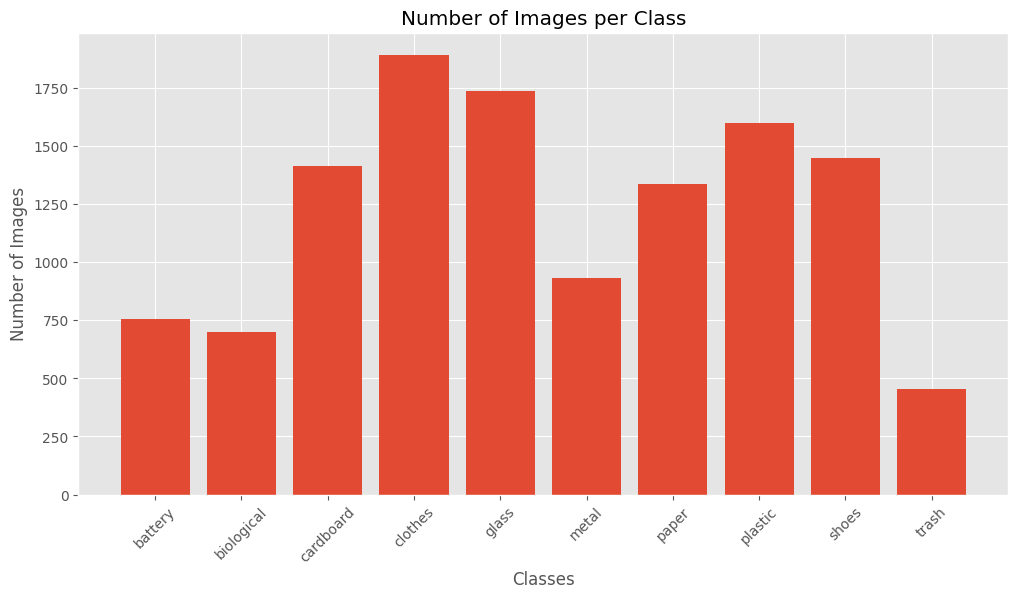

In [58]:
plt.figure(figsize=(12,6))
plt.bar(df["Class"], df["Images"])
plt.xticks(rotation=45)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")

plt.show()

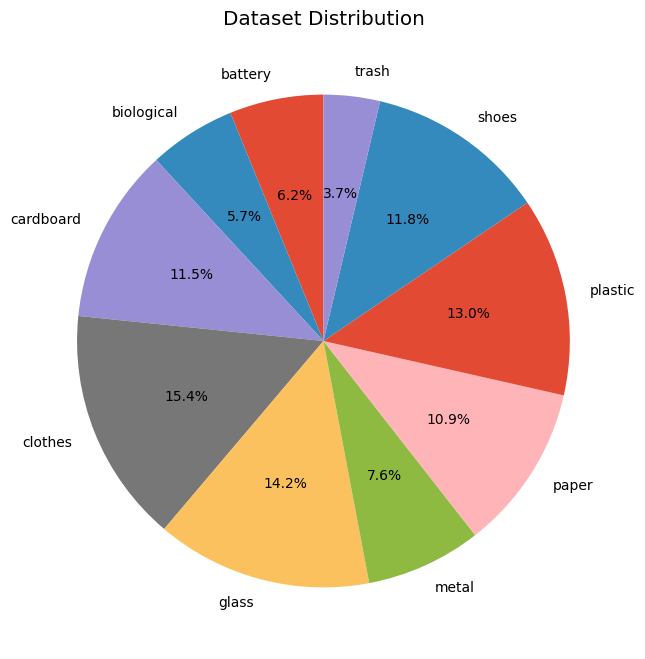

In [59]:
plt.figure(figsize=(8,8))

plt.pie(
    df["Images"],
    labels=df["Class"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Dataset Distribution")

plt.show()

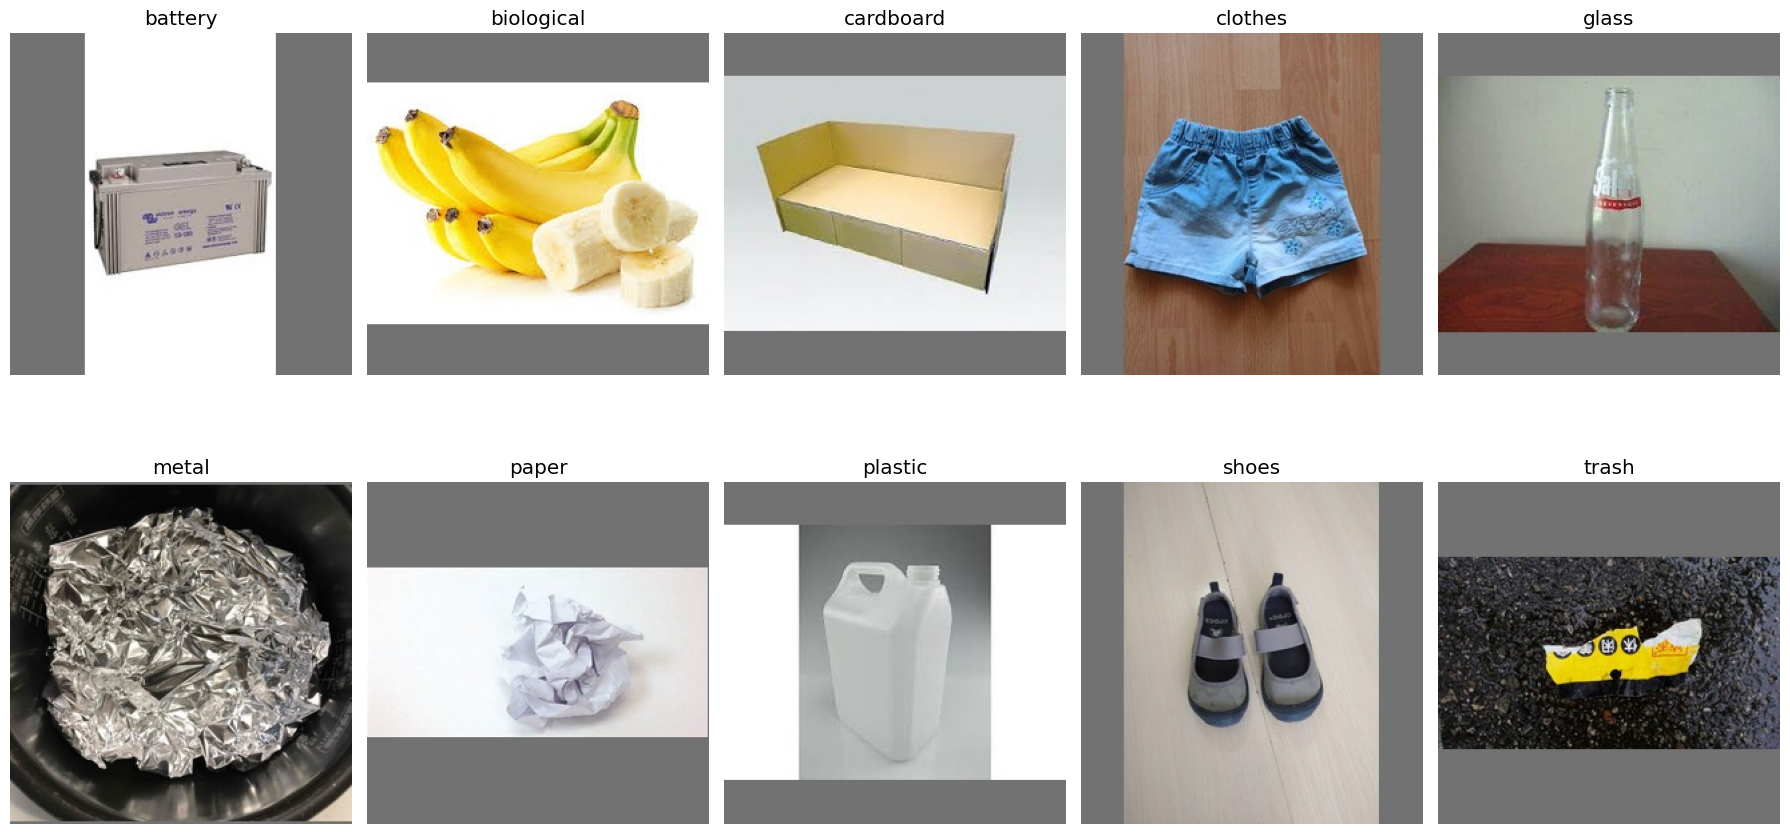

In [60]:
plt.figure(figsize=(18,10))

for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(DATASET_PATH, cls)))
    img_path = os.path.join(DATASET_PATH, cls, img_name)
    img = Image.open(img_path)
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()

plt.show()

In [61]:
widths = []
heights = []

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)

    for img_name in os.listdir(folder)[:100]:
        img = Image.open(os.path.join(folder, img_name))
        w,h = img.size
        widths.append(w)
        heights.append(h)

print("Unique Widths :", np.unique(widths))
print("Unique Heights:", np.unique(heights))

Unique Widths : [256]
Unique Heights: [256]


In [62]:
extensions = {}

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)

    for img in os.listdir(folder):
        ext = img.split(".")[-1].lower()
        extensions[ext] = extensions.get(ext,0)+1

extensions

{'jpg': 12258, 'jpeg': 1}

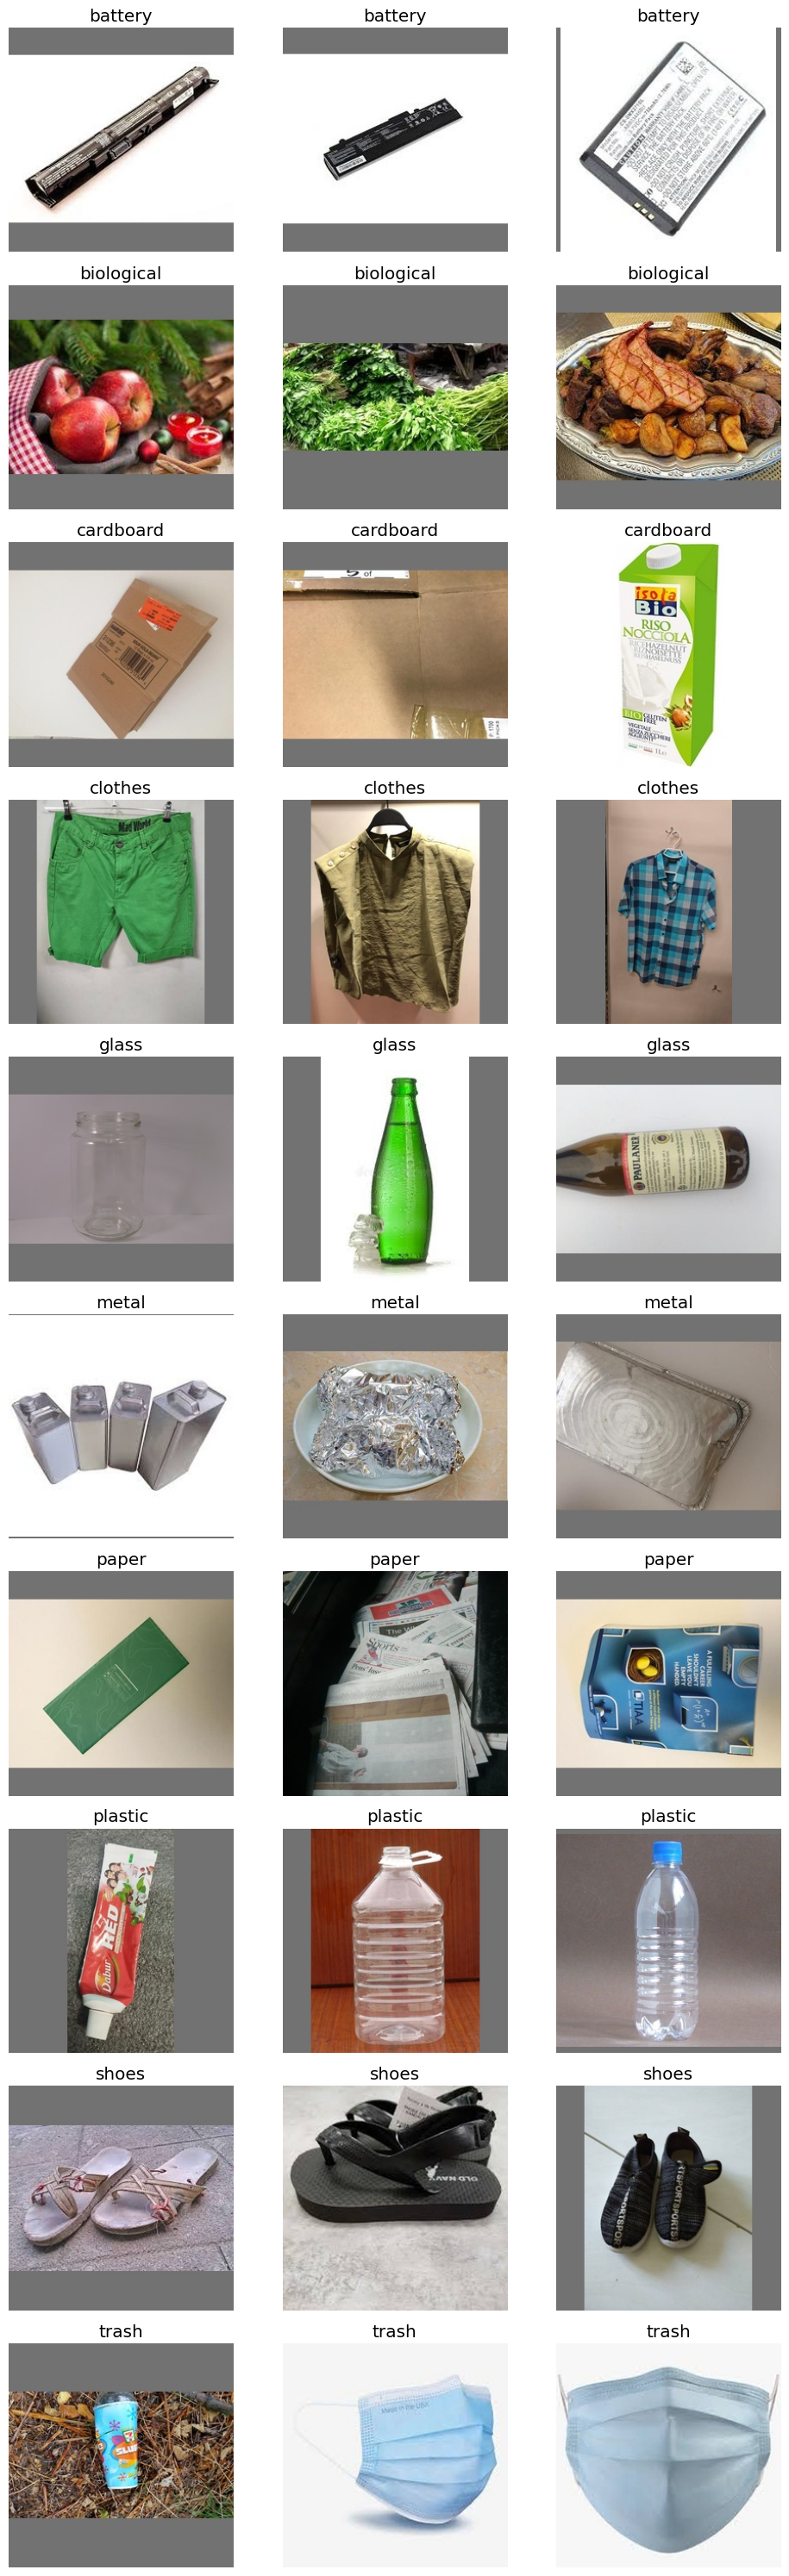

In [63]:
fig, axes = plt.subplots(10,3, figsize=(10,30))
for row, cls in enumerate(classes):
    folder = os.path.join(DATASET_PATH, cls)
    images = random.sample(os.listdir(folder),3)
    
    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(folder,img_name))
        axes[row,col].imshow(img)
        axes[row,col].set_title(cls)
        axes[row,col].axis("off")

plt.tight_layout()
plt.show()

In [64]:
bad_images = []
for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(folder):
        path = os.path.join(folder,img_name)
        try:
            Image.open(path).verify()
        except:
            bad_images.append(path)

print("Corrupted Images :",len(bad_images))

Corrupted Images : 0


In [65]:
import shutil
import os
import splitfolders

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

splitfolders.ratio(
    DATASET_PATH,
    output=OUTPUT_PATH,
    seed=42,
    ratio=(0.8, 0.1, 0.1),
    move=False   # نسخ بدل نقل - إلزامي هنا لإن input read-only
)


Copying files: 0 files [00:00, ? files/s]
Copying files: 112 files [00:00, 1118.56 files/s]
Copying files: 235 files [00:00, 1180.03 files/s]
Copying files: 363 files [00:00, 1224.26 files/s]
Copying files: 492 files [00:00, 1247.84 files/s]
Copying files: 617 files [00:00, 1244.75 files/s]
Copying files: 750 files [00:00, 1272.83 files/s]
Copying files: 883 files [00:00, 1289.54 files/s]
Copying files: 1012 files [00:00, 1217.95 files/s]
Copying files: 1143 files [00:00, 1243.91 files/s]
Copying files: 1276 files [00:01, 1269.46 files/s]
Copying files: 1412 files [00:01, 1296.05 files/s]
Copying files: 1543 files [00:01, 1295.93 files/s]
Copying files: 1674 files [00:01, 1298.24 files/s]
Copying files: 1807 files [00:01, 1307.73 files/s]
Copying files: 1939 files [00:01, 1310.43 files/s]
Copying files: 2071 files [00:01, 1293.29 files/s]
Copying files: 2201 files [00:01, 1294.73 files/s]
Copying files: 2331 files [00:01, 1285.64 files/s]
Copying files: 2460 files [00:01, 1275.37 file

In [66]:
train_path = os.path.join(OUTPUT_PATH, "train")
val_path   = os.path.join(OUTPUT_PATH, "val")
test_path  = os.path.join(OUTPUT_PATH, "test")

print(train_path)
print(val_path)
print(test_path)

/kaggle/working/garbage_dataset/train
/kaggle/working/garbage_dataset/val
/kaggle/working/garbage_dataset/test


In [67]:
## Build
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)


val_test_gen = ImageDataGenerator(
    rescale=1./255
)

In [68]:
## USE
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = train_gen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)
val_data = val_test_gen.flow_from_directory(
    val_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_data = val_test_gen.flow_from_directory(
    test_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

NUM_CLASSES = train_data.num_classes

Found 9802 images belonging to 10 classes.
Found 1221 images belonging to 10 classes.
Found 1236 images belonging to 10 classes.


In [69]:
## Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1785803482.888491      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [70]:
## Class weights(imbalance)
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))


In [71]:
## Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
]

In [72]:
## Train 
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/15


I0000 00:00:1785803498.742865     184 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


307/307 ━━━━━━━━━━━━━━━━━━━━ 140s 414ms/step - accuracy: 0.7687 - loss: 0.7090 - val_accuracy: 0.8690 - val_loss: 0.3795 - learning_rate: 0.0010
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 112s 364ms/step - accuracy: 0.8531 - loss: 0.4367 - val_accuracy: 0.8845 - val_loss: 0.3592 - learning_rate: 0.0010
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 110s 359ms/step - accuracy: 0.8715 - loss: 0.3677 - val_accuracy: 0.8960 - val_loss: 0.3180 - learning_rate: 0.0010
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 110s 357ms/step - accuracy: 0.8814 - loss: 0.3375 - val_accuracy: 0.8993 - val_loss: 0.3181 - learning_rate: 0.0010
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 110s 357ms/step - accuracy: 0.8931 - loss: 0.2992 - val_accuracy: 0.9025 - val_loss: 0.2995 - learning_rate: 0.0010
Epoch 6/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 111s 363ms/step - accuracy: 0.9039 - loss: 0.2730 - val_accuracy: 0.8976 - val_loss: 0.3136 - learning_rate: 0.0010
Epoch 7/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 113s 369ms/step - accuracy: 0.9092 

In [73]:
## Fine-tuning 
base_model.trainable = True
# Just unlock the last 30 layers, leave the rest frozen
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/10


2026-08-04 00:59:54.738970: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-04 00:59:54.935761: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


198/307 ━━━━━━━━━━━━━━━━━━━━ 38s 354ms/step - accuracy: 0.8038 - loss: 0.6901

2026-08-04 01:01:11.881192: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-04 01:01:12.076500: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


307/307 ━━━━━━━━━━━━━━━━━━━━ 140s 404ms/step - accuracy: 0.8404 - loss: 0.5142 - val_accuracy: 0.9066 - val_loss: 0.3001 - learning_rate: 1.0000e-05
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 110s 360ms/step - accuracy: 0.8805 - loss: 0.3467 - val_accuracy: 0.9075 - val_loss: 0.2983 - learning_rate: 1.0000e-05
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 112s 365ms/step - accuracy: 0.8981 - loss: 0.2935 - val_accuracy: 0.9156 - val_loss: 0.2832 - learning_rate: 1.0000e-05
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 112s 363ms/step - accuracy: 0.9077 - loss: 0.2536 - val_accuracy: 0.9156 - val_loss: 0.2818 - learning_rate: 5.0000e-06
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 110s 359ms/step - accuracy: 0.9073 - loss: 0.2498 - val_accuracy: 0.9115 - val_loss: 0.2790 - learning_rate: 5.0000e-06


In [74]:
## Evaluation
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - accuracy: 0.8932 - loss: 0.3634
Test Accuracy: 0.8932


In [75]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
test_data.reset()
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_data.classes

class_labels = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step
              precision    recall  f1-score   support

     battery       0.89      0.94      0.91        77
  biological       0.93      1.00      0.97        71
   cardboard       0.90      0.87      0.88       142
     clothes       0.97      0.99      0.98       190
       glass       0.89      0.90      0.89       175
       metal       0.80      0.83      0.81        93
       paper       0.85      0.82      0.84       135
     plastic       0.87      0.80      0.83       161
       shoes       0.93      0.97      0.95       146
       trash       0.74      0.76      0.75        46

    accuracy                           0.89      1236
   macro avg       0.88      0.89      0.88      1236
weighted avg       0.89      0.89      0.89      1236



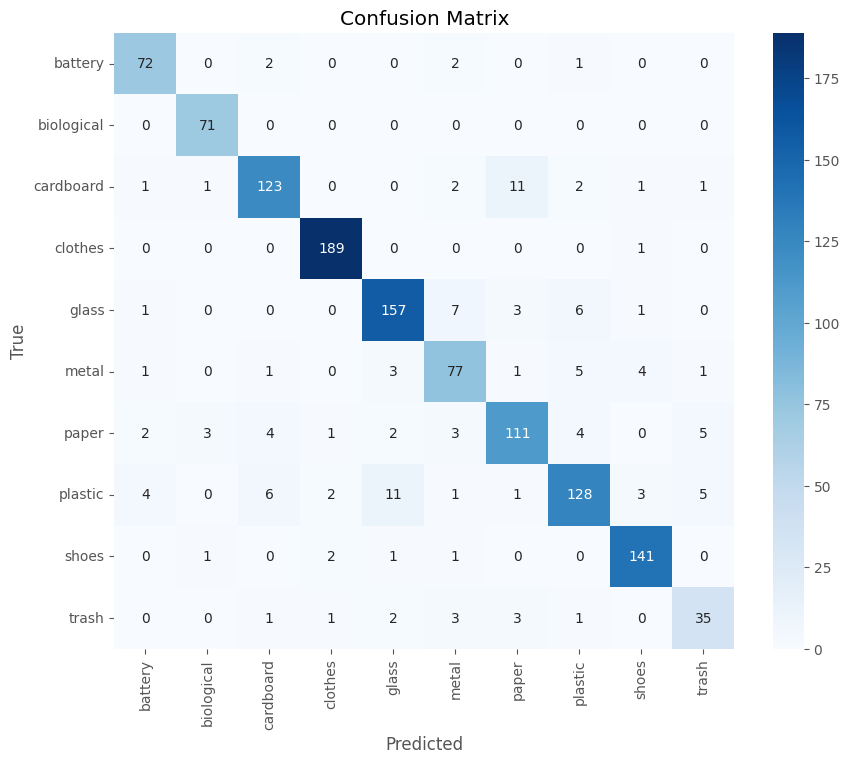

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [77]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_image(img_path, model, class_labels):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    predicted_class = class_labels[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence:.1f}%)")
    plt.show()

    top3_idx = np.argsort(preds)[-3:][::-1]
    print("Top 3 predictions:")
    for i in top3_idx:
        print(f"  {class_labels[i]}: {preds[i]*100:.2f}%")

    return predicted_class, confidence

True label: plastic
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


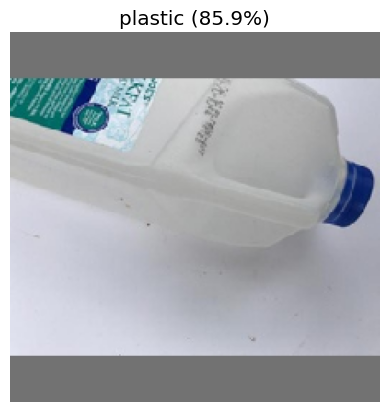

Top 3 predictions:
  plastic: 85.91%
  glass: 13.90%
  trash: 0.13%


('plastic', np.float32(85.913185))

In [78]:
import random

test_class = random.choice(os.listdir(test_path))
test_images = os.listdir(os.path.join(test_path, test_class))
random_img = random.choice(test_images)
img_path = os.path.join(test_path, test_class, random_img)

print(f"True label: {test_class}")
predict_image(img_path, model, class_labels)

In [79]:
!pip install gradio -q

import gradio as gr

def gradio_predict(img):
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array)[0]
    return {class_labels[i]: float(preds[i]) for i in range(len(class_labels))}

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="Garbage Classifier"
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://750132ead39947a750.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
